# SASHIMI-W: WDM suppression and surviving subhalo structure

## Goal
Calculate thermal-WDM populations in a $10^{12}M_\odot$ host at $z=0$.
Plot the transfer function, subhalo mass function, $V_{max}$–$r_{max}$ distributions
and cumulative satellite counts. The catalog-based reductions provide the physical
outputs illustrated by the historical `Examples.ipynb`.

This is a physical example of the current ITAMAE-backed calculation. Each figure
is computed below from the selected model, with explicit units and population
cuts. A joint grid refinement at the end measures numerical sensitivity for this
example; it does not establish simulation calibration or an observational limit.

## Setup
From this repository's migration checkout, install the pinned development environment:
```sh
uv sync --extra demo
uv run --no-sync python -m ipykernel install --user --name sashimi-w-demo --display-name "sashimi-w demo"
```
Select that kernel and **Restart Kernel and Run All**. Allow several minutes for
the population and refinement calculations. No input files are downloaded by the
cells. The output directory is local to the notebook. Historical examples are
preserved in [archive/](archive/); the independent migration audit is in
[scientific_validation.ipynb](scientific_validation.ipynb).

In [1]:
%matplotlib inline
import sys
import json
import time
import warnings
from pathlib import Path
from collections import Counter
from importlib.metadata import version
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from itamae.provenance import source_revision
from itamae.types import WeightedSubhaloCatalog
import itamae

plt.rcParams.update({"figure.figsize": (7.2, 4.5), "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.18,
                     "figure.constrained_layout.use": True})
COLORS = ["#0072B2", "#D55E00", "#009E73", "#555555"]
STYLES = ["-", "--", "-.", ":"]
output_dir = Path("outputs/usage_walkthrough")
output_dir.mkdir(parents=True, exist_ok=True)


def table(headers, rows):
    display(Markdown("| " + " | ".join(headers) + " |\n| " +
                     " | ".join(["---"] * len(headers)) + " |\n" +
                     "\n".join("| " + " | ".join(map(str, row)) + " |" for row in rows)))


def calculate(label, function):
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as observed:
        warnings.simplefilter("always", RuntimeWarning)
        result = function()
    print(f"{label}: {time.perf_counter() - start:.1f} s")
    if observed:
        counts = Counter(f"{item.category.__name__}: {item.message}" for item in observed)
        table(["Recorded warning", "Occurrences"], counts.items())
    return result


def check_catalog(catalog):
    weights = catalog.weight_final
    assert np.all(np.isfinite(weights)) and np.all(weights >= 0)
    assert weights.sum() > 0
    mass = catalog.columns["m_bound"]
    assert np.all(np.isfinite(mass)) and np.all(mass >= 0)
    return {"nodes": len(catalog), "expected_survivors": float(weights.sum()),
            "bound_mass_fraction": float(catalog.weighted_sum(mass) / 1e12),
            "N_bound_gt_1e8": float(weights[mass > 1e8].sum())}


def mass_function(catalog, edges, selection=None, column="m_bound"):
    selected = catalog if selection is None else catalog.select(selection)
    counts, _ = selected.weighted_histogram(column, bins=edges)
    return np.sqrt(edges[:-1] * edges[1:]), counts / np.diff(np.log(edges))



def accretion_bin_edges(catalog, group=6):
    # Bin boundaries lie between accretion-grid nodes, avoiding bin/grid beating.
    log_nodes = np.log(np.unique(catalog.columns["m200_acc"]))
    spacing = np.diff(log_nodes)
    np.testing.assert_allclose(spacing, spacing[0], rtol=1e-10)
    interior = (log_nodes[:-1] + log_nodes[1:]) / 2
    return np.exp(np.r_[log_nodes[0] - spacing[0]/2, interior[group-1::group],
                        log_nodes[-1] + spacing[-1]/2])


def cumulative(values, weights, thresholds):
    return np.array([weights[values > threshold].sum() for threshold in thresholds])


def save_catalog(catalog, name):
    path = output_dir / (name + ".npz")
    catalog.to_npz(path)
    restored = WeightedSubhaloCatalog.from_npz(path)
    np.testing.assert_array_equal(restored.weight_final, catalog.weight_final)
    for column in catalog.columns:
        np.testing.assert_array_equal(restored.columns[column], catalog.columns[column])
    assert restored.metadata == catalog.metadata
    return path

import sashimi_w
components = [("sashimi-itamae", "itamae", itamae), ("sashimi-w", "sashimi-w", sashimi_w)]
provenance = {dist: {"version": version(dist), "source_revision": source_revision(name, module_file=mod.__file__)}
              for dist, name, mod in components}
table(["Component", "Version", "Source revision"],
      [(name, info["version"], info["source_revision"]) for name, info in provenance.items()])
print("Python", sys.version.split()[0], "| NumPy", version("numpy"), "| SciPy", version("scipy"))

| Component | Version | Source revision |
| --- | --- | --- |
| sashimi-itamae | 0.2.0rc1 | 23d01e8758a88b061b87de9e488c38ec89fd8e4f |
| sashimi-w | 0.2.0rc1 | eebe141606ad84bcb22f09c66adb966d92cc6125 |

Python 3.11.15 | NumPy 2.4.6 | SciPy 1.17.1


## 1. Set the thermal relic mass and inspect the transfer function

All cases use the package's existing WMAP7 background and Viel coefficients.
The adopted power suppression is the squared transfer amplitude (q10).
The amplitude-half scale has $T=1/2$, hence $P_{WDM}/P_{CDM}=1/4$; the distinct
power-half scale is also shown in the table. The proposed Vogel coefficients
remain deferred. No observation-derived mass limit is inferred here.

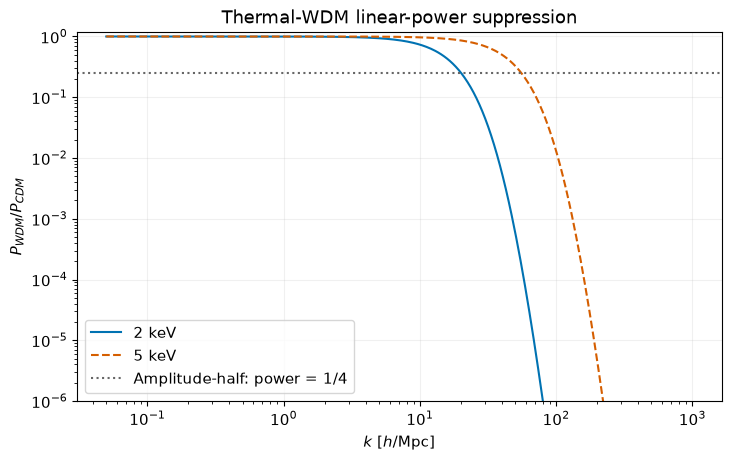

| Mass [keV] | Amplitude-half k [h/Mpc] | Power-half k [h/Mpc] |
| --- | --- | --- |
| 2 | 20.11 | 14.5 |
| 5 | 55.62 | 40.1 |

In [2]:
from sashimi_w import Subhalos
particle_masses = [2., 5.]
models = {mass: Subhalos(mass) for mass in particle_masses}
k = np.geomspace(.05, 1000, 400)  # h/Mpc
fig, ax = plt.subplots()
rows = []
for (mass, model), color, style in zip(models.items(), COLORS, STYLES):
    suppression = model.power_ratio(k)
    ax.loglog(k, suppression, style, color=color, label=f"{mass:g} keV")
    half_amplitude = model.half_mode_wavenumber()
    half_power = model.half_mode_wavenumber(power_ratio=.5)
    np.testing.assert_allclose(model.power_ratio(half_amplitude), .25, rtol=1e-12)
    rows.append((f"{mass:g}", f"{half_amplitude:.4g}", f"{half_power:.4g}"))
ax.axhline(.25, color="0.4", ls=":", label="Amplitude-half: power = 1/4")
ax.set(xlabel=r"$k$ [$h$/Mpc]", ylabel=r"$P_{WDM}/P_{CDM}$", ylim=(1e-6, 1.2), title="Thermal-WDM linear-power suppression")
ax.legend()
plt.show()
table(["Mass [keV]", "Amplitude-half k [h/Mpc]", "Power-half k [h/Mpc]"], rows)

## 2. Compute the surviving populations

Use $M_{200,acc}=10^5$–$10^{11}M_\odot$, $0<z_{acc}\le7$, and the same numerical
grid in both cases. `weight_final` includes the tidal survival factor. The WDM
accretion implementation can record floating-point warnings from intermediate
expressions outside its selected support; any warnings are displayed and all
stored masses and final weights are checked. A failed catalog check stops the notebook.

In [3]:
parameters = dict(M0=1e12, redshift=0., dz=.05, zmax=7., N_ma=192,
                  N_herm=5, N_hermNa=64, sigmalogc=.128, logmamin=5.,
                  logmamax=11., sigmafac=0, profile_change=True)
catalogs = {}
rows = []
for mass, model in models.items():
    current = calculate(f"WDM {mass:g} keV", lambda: model.rs_rhos_catalog_calc(**parameters))
    catalogs[mass] = current
    metrics = check_catalog(current)
    rows.append((f"{mass:g}", f"{metrics['expected_survivors']:.3f}",
                 f"{metrics['bound_mass_fraction']:.5f}", f"{metrics['N_bound_gt_1e8']:.3f}"))
table(["WDM [keV]", "Expected survivors", "Bound mass / host mass", "N(bound mass > 1e8 Msun)"], rows)
catalog = catalogs[2.]
mass_edges = np.geomspace(1e6, 1e11, 31)
print("Physics:", catalog.metadata["calculation_specification"])

WDM 2 keV: 177.9 s


| Recorded warning | Occurrences |
| --- | --- |
| RuntimeWarning: invalid value encountered in power | 1 |
| RuntimeWarning: overflow encountered in exp | 1 |

WDM 5 keV: 190.4 s


| Recorded warning | Occurrences |
| --- | --- |
| RuntimeWarning: invalid value encountered in power | 1 |
| RuntimeWarning: overflow encountered in exp | 1 |

| WDM [keV] | Expected survivors | Bound mass / host mass | N(bound mass > 1e8 Msun) |
| --- | --- | --- | --- |
| 2 | 8.886 | 0.04297 | 7.326 |
| 5 | 82.258 | 0.07000 | 34.753 |

Physics: sashimi-w:thermal-wdm-q10:2026-09-11:v2


## 3. Plot the subhalo mass functions

Each bin sums surviving expected counts and is divided by its width in $\ln m$.
The left panel uses bound mass at $z=0$. The right panel shows both bound and
accretion mass for the 2-keV survivors; changing coordinates does not restore
objects that were disrupted. The lower plotted mass is above the input floor,
although this alone does not prove completeness under extension of that floor.

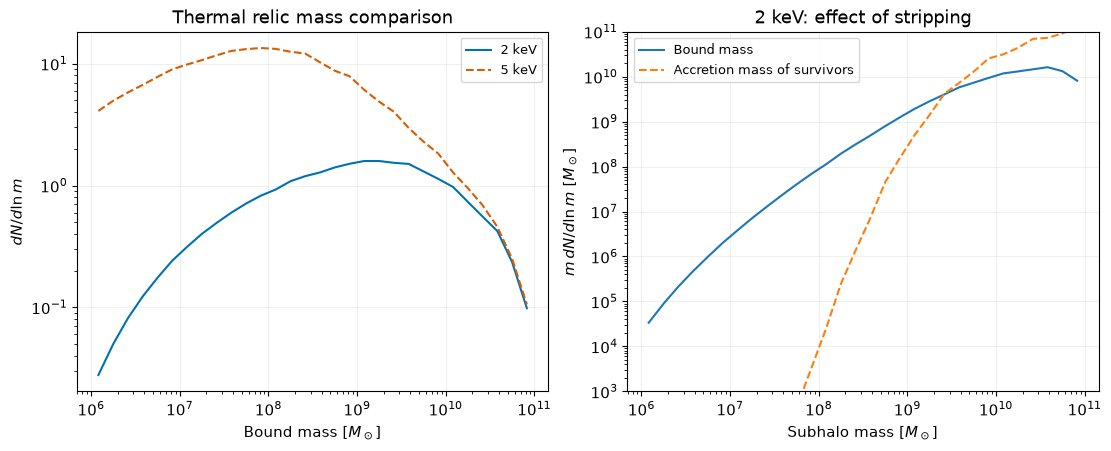

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for (mass_wdm, current), color, style in zip(catalogs.items(), COLORS, STYLES):
    mass, dndlnm = mass_function(current, mass_edges)
    axes[0].loglog(mass, np.where(dndlnm > 0, dndlnm, np.nan), style, color=color, label=f"{mass_wdm:g} keV")
for column, label, style in [("m_bound", "Bound mass", "-"), ("m200_acc", "Accretion mass of survivors", "--")]:
    mass, dndlnm = mass_function(catalog, mass_edges, column=column)
    axes[1].loglog(mass, np.where(dndlnm > 0, mass*dndlnm, np.nan), style, label=label)
axes[0].set(xlabel=r"Bound mass [$M_\odot$]", ylabel=r"$dN/d\ln m$", title="Thermal relic mass comparison")
axes[1].set(xlabel=r"Subhalo mass [$M_\odot$]", ylabel=r"$m\,dN/d\ln m$ [$M_\odot$]", title="2 keV: effect of stripping", ylim=(1e3, 1e11))
for ax in axes: ax.legend(fontsize=9)
plt.show()

## 4. Plot $V_{max}$ against $r_{max}$

Select current bound mass $>10^8M_\odot$ in each case. Convert canonical catalog
lengths from Mpc to kpc and densities to $M_\odot$/kpc³, then use the same NFW
relations as the public satellite observable. These are NFW structural parameters;
$r_{max}=2.163r_s$ can exceed the tidal radius. The color scale is shared and
represents expected counts per dex², including survival.

WDM 2 keV: 7.326 selected; 7.326 inside displayed axes
WDM 5 keV: 34.753 selected; 34.753 inside displayed axes


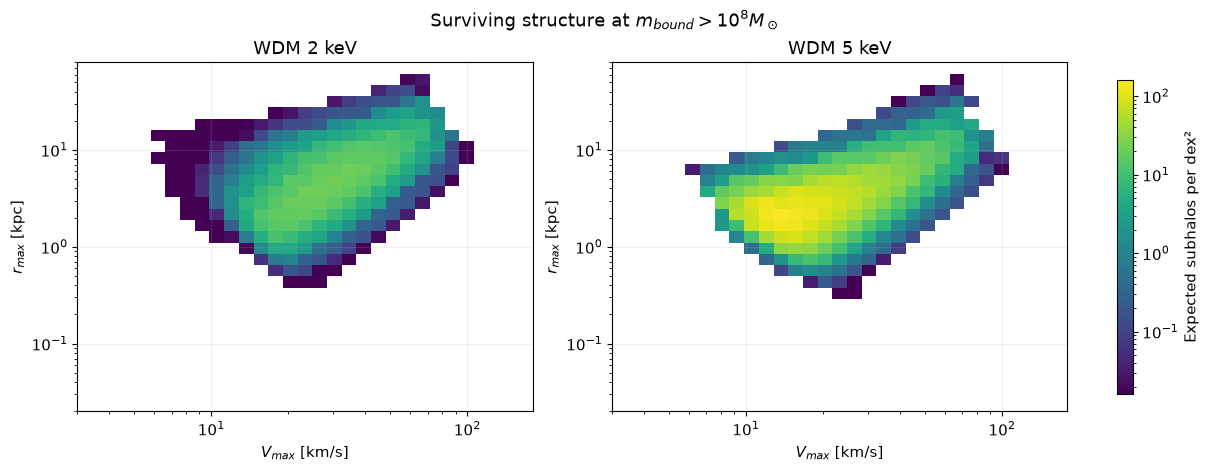

In [5]:
G_kpc = sashimi_w.G * sashimi_w.Msolar / sashimi_w.kpc / (sashimi_w.km/sashimi_w.s)**2


def nfw_observables(current, accretion=False):
    suffix = "_acc" if accretion else ""
    rs = 1000 * current.columns["r_s" + suffix]
    rhos = current.columns["rho_s" + suffix] / 1e9
    vmax = np.sqrt(4*np.pi*G_kpc*rhos/4.625) * rs
    return vmax, 2.163*rs


structure_views = []
for mass_wdm, current in catalogs.items():
    vmax, rmax = nfw_observables(current)
    select = (current.columns["m_bound"] > 1e8) & (current.weight_final > 0)
    structure_views.append((f"WDM {mass_wdm:g} keV", vmax[select], rmax[select], current.weight_final[select]))

from matplotlib.colors import LogNorm
v_edges = np.geomspace(3, 180, 32)
r_edges = np.geomspace(.02, 80, 32)
structure_histograms = []
for label, vx, ry, weights in structure_views:
    counts, _, _ = np.histogram2d(vx, ry, bins=(v_edges, r_edges), weights=weights)
    area = np.diff(np.log10(v_edges))[:, None] * np.diff(np.log10(r_edges))[None, :]
    structure_histograms.append(counts / area)
    print(f"{label}: {weights.sum():.3f} selected; {counts.sum():.3f} inside displayed axes")
maximum = max(hist.max() for hist in structure_histograms)
fig, axes = plt.subplots(1, len(structure_views), figsize=(6*len(structure_views), 4.6), squeeze=False)
for ax, (label, _, _, _), hist in zip(axes[0], structure_views, structure_histograms):
    mesh = ax.pcolormesh(v_edges, r_edges, np.ma.masked_less_equal(hist.T, 0),
                         norm=LogNorm(vmin=max(maximum*1e-4, 1e-4), vmax=maximum), cmap="viridis")
    ax.set(xscale="log", yscale="log", xlabel=r"$V_{max}$ [km/s]", ylabel=r"$r_{max}$ [kpc]", title=label)
fig.colorbar(mesh, ax=axes[0].tolist(), label="Expected subhalos per dex²", shrink=.9)
fig.suptitle(r"Surviving structure at $m_{bound}>10^8 M_\odot$")
plt.show()

## 5. Apply a satellite-formation cut

The strict $M_{peak}>10^8M_\odot$ cut selects potential galaxy hosts by their
accretion mass. The alternative $V_{peak}>18$ km/s selects by their initial NFW
maximum speed. Curves below are direct weighted sums $N(x>x_{threshold})$ for
survivors. This is the catalog-based counterpart of `N_sat` and `N_sat_Vthres`,
which recompute the population on each call. Galaxy occupation and observational
completeness are not fitted in this example.

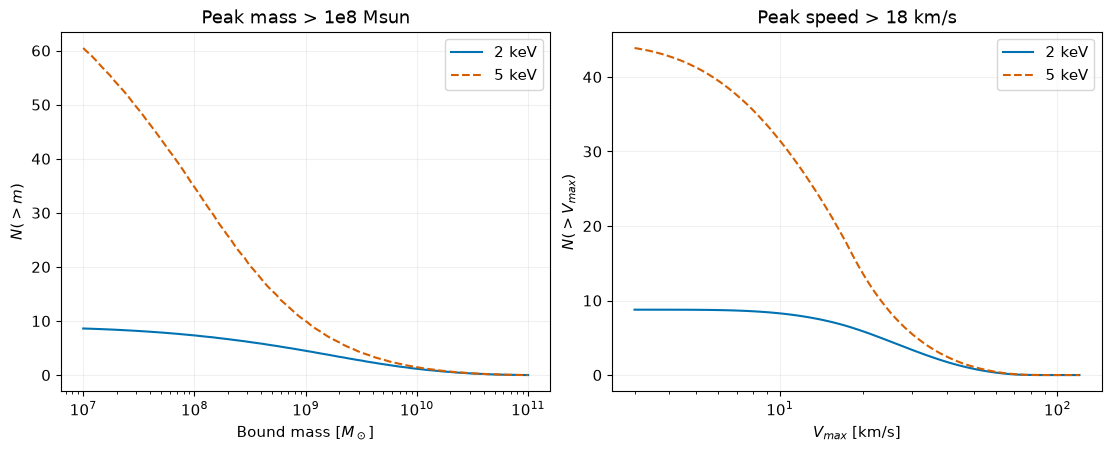

| WDM [keV] | N: peak mass cut | N: peak velocity cut |
| --- | --- | --- |
| 2 | 8.886 | 8.770 |
| 5 | 77.857 | 44.442 |

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
rows = []
for (mass_wdm, current), color, style in zip(catalogs.items(), COLORS, STYLES):
    vmax, _ = nfw_observables(current)
    vpeak, _ = nfw_observables(current, accretion=True)
    peak_mass_cut = current.columns["m200_acc"] > 1e8
    peak_velocity_cut = vpeak > 18
    mass_thresholds = np.geomspace(1e7, 1e11, 100)
    velocity_thresholds = np.geomspace(3, 120, 100)
    for ax, values, thresholds, select in [
        (axes[0], current.columns["m_bound"], mass_thresholds, peak_mass_cut),
        (axes[1], vmax, velocity_thresholds, peak_velocity_cut)]:
        counts = cumulative(values[select], current.weight_final[select], thresholds)
        assert np.all(np.diff(counts) <= 0)
        ax.plot(thresholds, counts, style, color=color, label=f"{mass_wdm:g} keV")
    rows.append((f"{mass_wdm:g}", f"{current.weight_final[peak_mass_cut].sum():.3f}",
                 f"{current.weight_final[peak_velocity_cut].sum():.3f}"))
axes[0].set(xscale="log", xlabel=r"Bound mass [$M_\odot$]", ylabel=r"$N(>m)$", title="Peak mass > 1e8 Msun")
axes[1].set(xscale="log", xlabel=r"$V_{max}$ [km/s]", ylabel=r"$N(>V_{max})$", title="Peak speed > 18 km/s")
for ax in axes: ax.legend()
plt.show()
table(["WDM [keV]", "N: peak mass cut", "N: peak velocity cut"], rows)

## Checks: refine the 2-keV population

This repeats the example with a smaller redshift step and larger mass and
quadrature grids. Remaining differences are displayed, not converted to an
observational error bar. The mass-function comparison tests the shape as well as
integrated counts. See [resolution limits](../docs/resolution-and-review.md) for
separate solver/grid evidence and the accepted limits of the default prescription.

Refined 2-keV population: 462.0 s


| Recorded warning | Occurrences |
| --- | --- |
| RuntimeWarning: invalid value encountered in power | 1 |
| RuntimeWarning: overflow encountered in exp | 1 |

| Quantity | Displayed grid | Refined grid | Change |
| --- | --- | --- | --- |
| expected_survivors | 8.88561 | 9.01803 | +1.490% |
| bound_mass_fraction | 0.0429734 | 0.0447327 | +4.094% |
| N_bound_gt_1e8 | 7.32574 | 7.44608 | +1.643% |

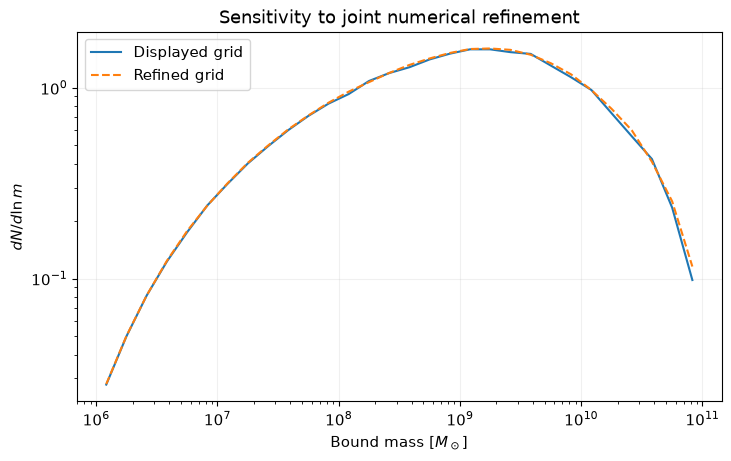

Catalog saved and checked: outputs/usage_walkthrough/catalog.npz


Refined catalog saved and checked: outputs/usage_walkthrough/catalog-refined.npz
Saved: outputs/usage_walkthrough/wdm-2-keV.npz


Saved: outputs/usage_walkthrough/wdm-5-keV.npz


In [7]:
refined_parameters = {**parameters, "dz": .025, "N_ma": 256, "N_herm": 7, "N_hermNa": 96}
refined_catalog = calculate("Refined 2-keV population", lambda: models[2.].rs_rhos_catalog_calc(**refined_parameters))

coarse_metrics, fine_metrics = check_catalog(catalog), check_catalog(refined_catalog)
refinement_rows = []
for metric in ("expected_survivors", "bound_mass_fraction", "N_bound_gt_1e8"):
    first, second = coarse_metrics[metric], fine_metrics[metric]
    delta = 100 * (second / first - 1)
    refinement_rows.append((metric, f"{first:.6g}", f"{second:.6g}", f"{delta:+.3f}%"))
table(["Quantity", "Displayed grid", "Refined grid", "Change"], refinement_rows)
fig, ax = plt.subplots()
for cat, label, style in [(catalog, "Displayed grid", "-"), (refined_catalog, "Refined grid", "--")]:
    mass, dndlnm = mass_function(cat, mass_edges)
    ax.loglog(mass, np.where(dndlnm > 0, dndlnm, np.nan), style, label=label)
ax.set(xlabel=r"Bound mass [$M_\odot$]", ylabel=r"$dN/d\ln m$", title="Sensitivity to joint numerical refinement")
ax.legend()
plt.show()
report = {"provenance": provenance, "parameters": parameters, "refined_parameters": refined_parameters,
          "displayed": coarse_metrics, "refined": fine_metrics}
(output_dir / "resolution-summary.json").write_text(json.dumps(report, indent=2) + "\n")
print("Catalog saved and checked:", save_catalog(catalog, "catalog"))
print("Refined catalog saved and checked:", save_catalog(refined_catalog, "catalog-refined"))

for mass_wdm, current in catalogs.items():
    print("Saved:", save_catalog(current, f"wdm-{mass_wdm:g}-keV"))

## Next steps

The mass functions, structural distributions and satellite counts are real
outputs of the same ITAMAE-backed WDM catalogs. Compare particle masses within
this fixed background and prescription; mixing a CDM curve with a different
cosmology would not isolate the transfer-function effect. Quantitative constraints
require grid/domain convergence, an occupation/selection model and external
validation. The [q10 adoption record](../docs/q10-adoption.md) defines the retained
prescription, while [scientific validation](scientific_validation.ipynb) preserves
the independent migration comparisons.